# EDA on Titanic
## 1. Load & Understand Data
- Load CSV, basic inspection

In [60]:
#Import libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
#Import dataset from seaborn 
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
print(f"rows {df.shape[0]} columns {df.shape[1]} in the dataset")

rows 891 columns 15 in the dataset


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [9]:
df.dtypes # Checking dtypes so that it is easy to change dataype of a certain column while cleaning or visualizing data

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
df.drop('class', axis=1, inplace=True) #We've encountered redundent columns pclass and class so dropping one column makes senseb

In [13]:
df.drop('embarked', axis=1, inplace=True) #We've encountered redundent columns pclass and class so dropping one column makes sense

## Variables Description:
- survived: Survival status of the passenger — 1 = survived, 0 = did not survive
- pclass: Ticket class — 1 = 1st (upper class), 2 = 2nd (middle class), 3 = 3rd (working class)
- sex: Gender of the passenger — male or female
- age: Age of the passenger in years
- sibsp: Number of siblings and/or spouses aboard with the passenger
- parch: Number of parents and/or children aboard with the passenger
- fare: Ticket fare paid by the passenger
- who: Passenger type — man, woman, or child (based on gender and age)
- adult_male: Boolean — True if passenger is an adult male, else False
- deck: Cabin deck — represented by letters like A, B, C, etc.
- embark_town: Port of embarkation — Cherbourg, Queenstown, or Southampton
- alive: Survival status in text form — yes or no
- alone: Boolean — True if passenger had no family aboard, else False

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   who          891 non-null    object  
 8   adult_male   891 non-null    bool    
 9   deck         203 non-null    category
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(4)
memory usage: 72.7+ KB


In [ ]:
## Getting and visualizaing missing values 

In [16]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

Text(0.5, 1.0, 'Heatmap of missing values')

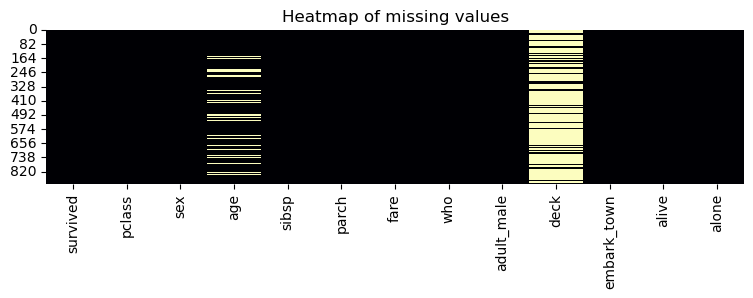

In [23]:
plt.figure(figsize=(9,2))
sns.heatmap(df.isnull(),cmap='magma',cbar=False)
plt.title("Heatmap of missing values")

In [24]:
(df.isnull().mean() * 100).sort_values(ascending=False)
#With tihs we can understand that why the embark_town doesn't not show on heatmap because it has very less number missing values

deck           77.216611
age            19.865320
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [25]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')

## 2. Univariate Variable Analysis

In this step of EDA, we analyze individual variables one at a time to understand their distributions and characteristics.  
We will explore both categorical and numerical variables separately using appropriate visualizations to gain initial insights into the data.


### Categorical Values

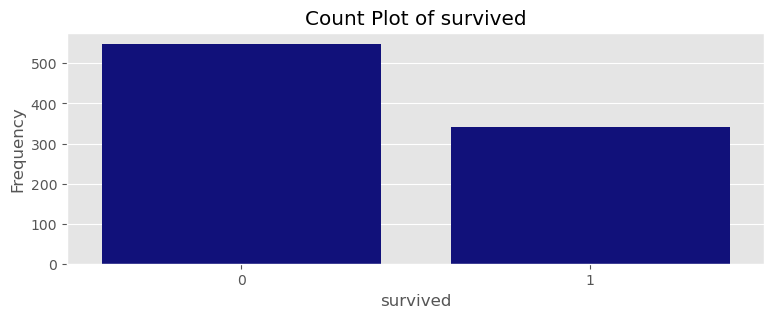

survived:
survived
0    549
1    342
Name: count, dtype: int64



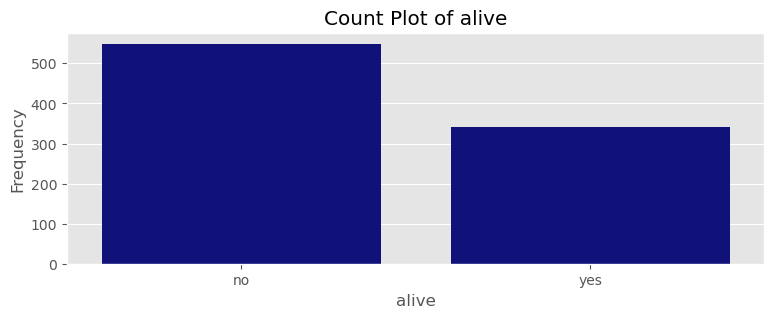

alive:
alive
no     549
yes    342
Name: count, dtype: int64



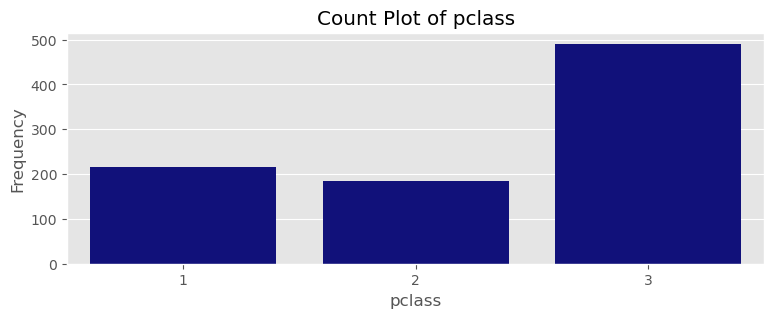

pclass:
pclass
3    491
1    216
2    184
Name: count, dtype: int64



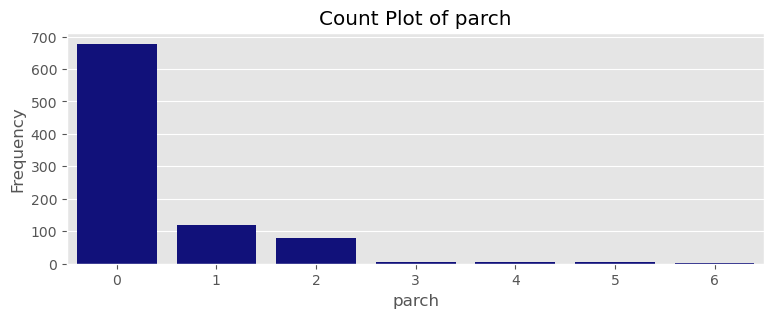

parch:
parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64



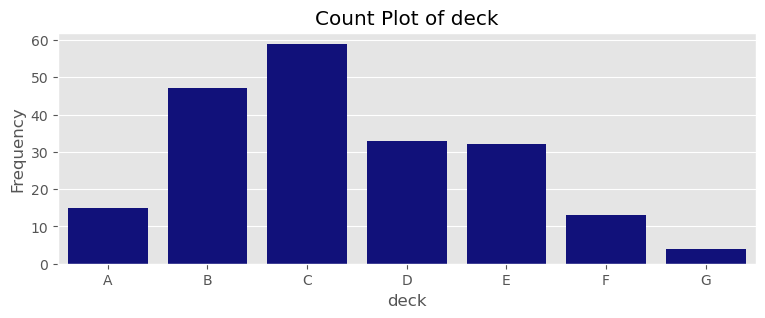

deck:
deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64



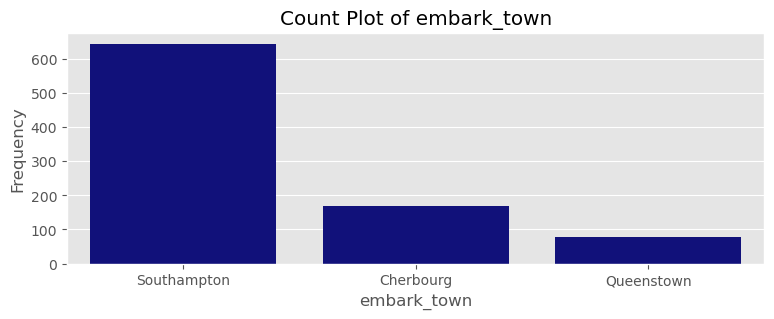

embark_town:
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64



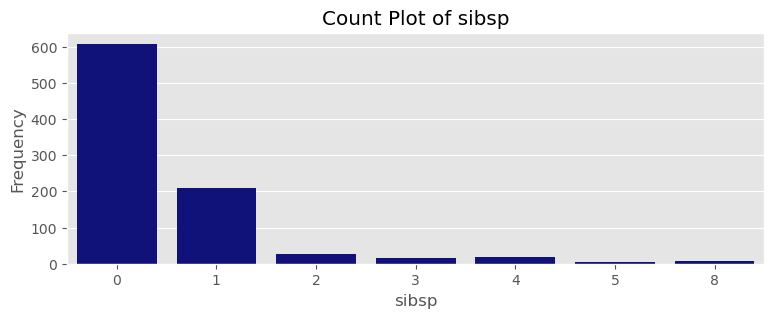

sibsp:
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64



In [79]:
def plot_count(var):
    plt.figure(figsize=(9, 3))
    sns.countplot(data=df, x=var,color='darkblue')
    plt.title(f"Count Plot of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()
    print(f"{var}:\n{df[var].value_counts()}\n")

category = ['survived', 'alive', 'pclass', 'parch', 'deck', 'embark_town', 'sibsp']

for col in category:
    plot_count(col)

In [51]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,no,True


### Numerical Values

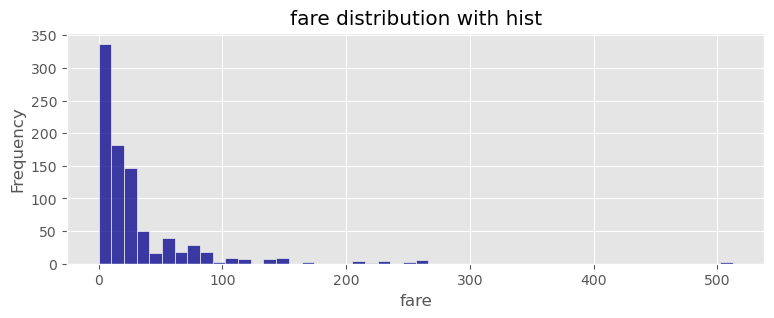

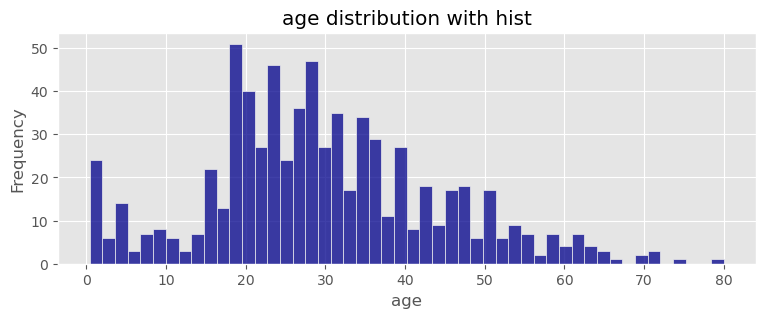

In [78]:
def hist_plot(val):
    plt.figure(figsize=(9,3))
    sns.histplot(df[val],bins=50,color='darkblue')
    plt.ylabel('Frequency')
    plt.xlabel(val)
    plt.title("{} distribution with hist".format(val)) #format is used to replace {} with the values that val variable is holding.
    plt.show()

Numeric_Vars = ['fare','age']
for n in Numeric_Vars:
    hist_plot(n)
    